## Digit Recognition Using MNIST - CNN

In [1]:
#to suppress warnings:
def warn(*args, **kwargs):
    pass

import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')


import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt #visualizations
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix #to evaluate accuracy of a classification

#from keras.utils.np_utils import to_categorical #for one hot encoding/ vecotrization of varibles
from keras.utils import to_categorical
from keras.models import Sequential #Sequential Model/API for our model

#Dense allows us to connect each neuron/output 
#Dropout layer randomly ses input units to zero, batchnorm - stabilizes the learning
#Conv2D a 2x2 Conv Kernel # Flatten - flattens the image, MaxPool2D takes the max when filtering
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization

from keras.optimizers import Adam #for optimization
from tensorflow.keras.preprocessing.image import ImageDataGenerator #random data from our train set
from keras.callbacks import LearningRateScheduler # adjust LR each epoch

In [1]:


from pathlib import Path
import pandas as pd

BASE_PATH = Path(".")

train_data = pd.read_csv(BASE_PATH / "train.csv")
test_data = pd.read_csv(BASE_PATH / "test.csv")
output_data = pd.read_csv(BASE_PATH / "sample_submission.csv")

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("Submission shape:", output_data.shape)

Train shape: (42000, 785)
Test shape: (28000, 784)
Submission shape: (28000, 2)


In [4]:
print(train_data.shape, test_data.shape)

(42000, 785) (28000, 784)


In [5]:
# Looking at a few rows from the data isn't a bad idea.
train_data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
train_data.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [7]:
train_data.isna().sum().any()

np.False_

In [8]:
test_data.isna().sum().any()

np.False_

In [9]:
mnist_train_data = train_data.iloc[:, 1:]
mnist_train_label = train_data.loc[:, 'label']

mnist_train_data = mnist_train_data/255


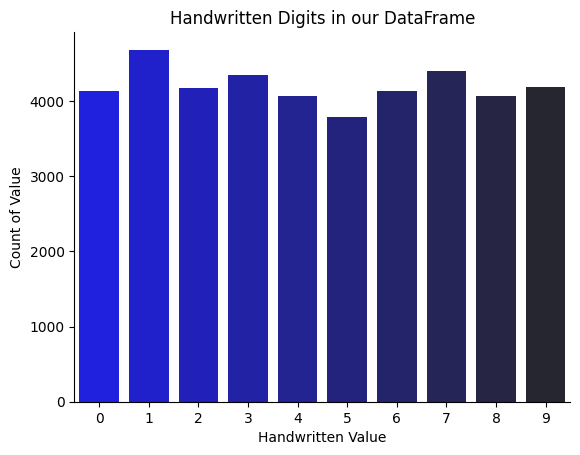

In [10]:
import seaborn as sns
plot_df = mnist_train_label.value_counts().to_frame(name='count')
plot_df.reset_index(inplace=True)
plot_df.rename(columns={'index': 'handwritten_no'},inplace=True)

sns.barplot(data=plot_df,x='label',y='count',palette='dark:b_r')
plt.xlabel("Handwritten Value")
plt.ylabel("Count of Value")
plt.title("Handwritten Digits in our DataFrame")
sns.despine()

> All values from 0 to 1 are in our dataframe so we can proceed.

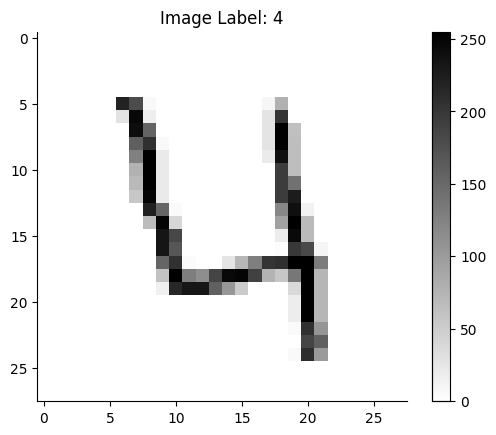

In [11]:
digit = train_data.loc[3, 'pixel0':]
arr = np.array(digit)

image_arr = np.reshape(arr, (28,28))
dig_img = plt.imshow(image_arr, cmap=plt.cm.binary)
plt.colorbar(dig_img)
plt.title("Image Label: {}".format(train_data.loc[3, 'label']))
sns.despine()

In [12]:
train_data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


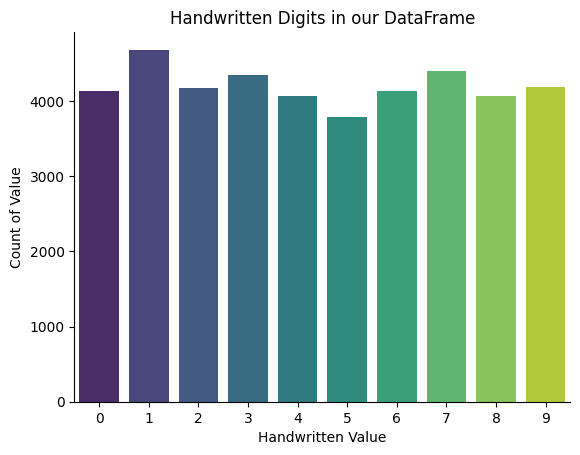

In [13]:
# Create a DataFrame for the labels
labels_df = pd.DataFrame(train_data, columns=['label'])

# Plot the distribution of digits
sns.countplot(data=labels_df, x='label', palette='viridis')
plt.xlabel("Handwritten Value")
plt.ylabel("Count of Value")
plt.title("Handwritten Digits in our DataFrame")
sns.despine()
plt.show()

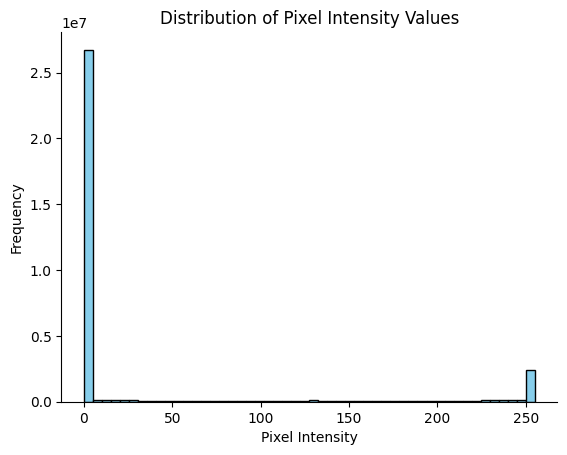

In [14]:
# Flatten the dataset to combine pixel values
pixel_values = train_data.drop(columns=['label']).to_numpy().flatten()
#pixel_values = train_data.flatten()

# Plot the histogram of pixel intensities
plt.hist(pixel_values, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Pixel Intensity Values")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
sns.despine()
plt.show()

## PCA

In [15]:
#Before feeding our data to PCA we'll have to standardize our data
# StandardScaler will convert our dataframe to a mean of 0 and standard deviation of 1
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
standardized_df = standard_scaler.fit_transform(mnist_train_data)

from sklearn import decomposition
pca = decomposition.PCA()
pca.n_components = 2
pca_data = pca.fit_transform(standardized_df)
pca_data.shape

(42000, 2)

In [16]:
standardized_df.shape

(42000, 784)

In [17]:
pd.DataFrame(pca_data)

,0,1
0,-5.140478,-5.226445
1,19.292332,6.032996
2,-7.644503,-1.705813
3,-0.474207,5.836139
4,26.559574,6.024818
...,...,...
41995,13.678849,-1.350366
41996,-8.869582,-1.187360
41997,0.495391,7.076277
41998,2.307240,-4.344513


In [18]:
standardized_df

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(42000, 784))

In [19]:
pca_data = pd.DataFrame(data=pca_data,columns=['PC1', 'PC2'])
label = pd.DataFrame(mnist_train_label)
pca_data['label'] = mnist_train_label
pca_data

,PC1,PC2,label
0,-5.140478,-5.226445,1
1,19.292332,6.032996,0
2,-7.644503,-1.705813,1
3,-0.474207,5.836139,4
4,26.559574,6.024818,0
...,...,...,...
41995,13.678849,-1.350366,0
41996,-8.869582,-1.187360,1
41997,0.495391,7.076277,7
41998,2.307240,-4.344513,6


In [20]:

label = pd.DataFrame(mnist_train_label)
pca_data = pd.DataFrame(data=pca_data,columns=['PC1', 'PC2'])
pca_data['label'] = mnist_train_label

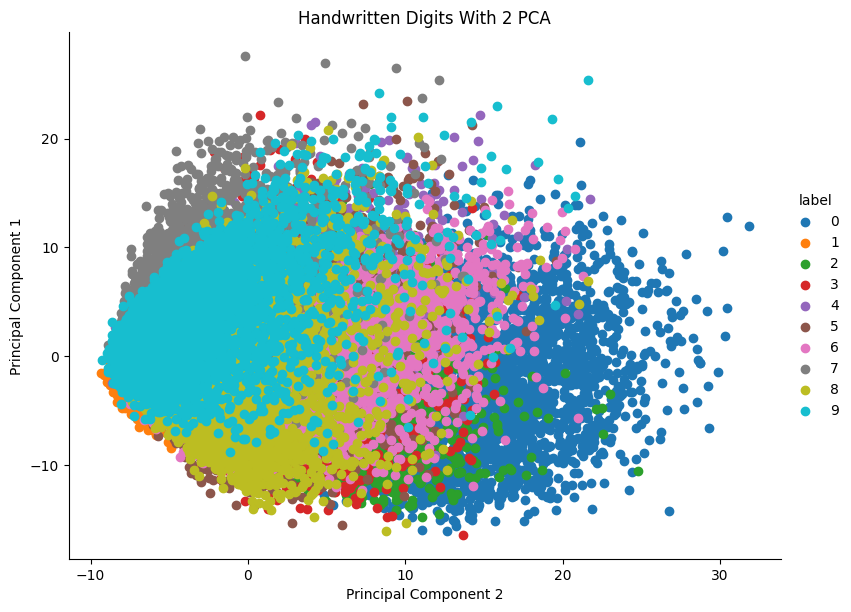

In [21]:

sns.FacetGrid(pca_data,hue='label',height=6, aspect=8/6).map(plt.scatter, 'PC1','PC2').add_legend()
sns.despine()
plt.xlabel("Principal Component 2")
plt.ylabel("Principal Component 1")
plt.title("Handwritten Digits With 2 PCA")
plt.show()

> The graph clearly demonstrates that clusters that the numbers form interms of their similarity. Also, rememember our assumption that a few features in the digits the likes of 3 or 8 would have commonality so they would overlap. It's clear to see that they do.

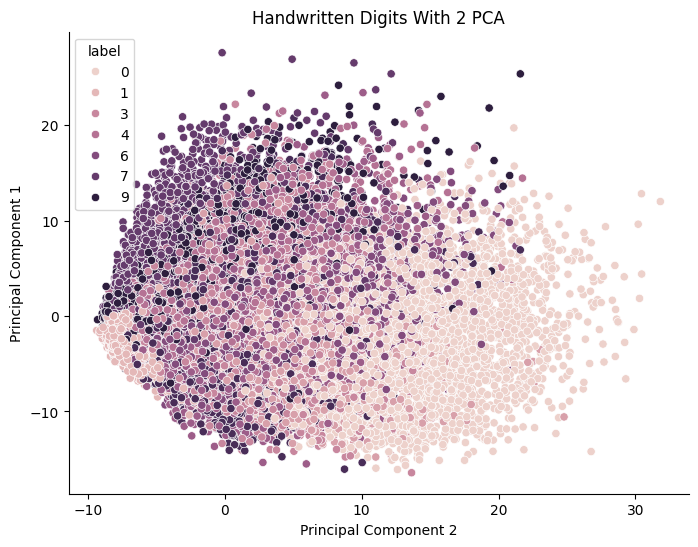

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_data, x='PC1', y='PC2', hue='label')
sns.despine()
plt.xlabel("Principal Component 2")
plt.ylabel("Principal Component 1")
plt.title("Handwritten Digits With 2 PCA")
plt.show()

### Create a model

In [24]:
from pathlib import Path
import numpy as np
from sklearn.model_selection import train_test_split

BASE_PATH = Path(
    r"D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn"
)

train_ = BASE_PATH / "train.csv"
test_ = BASE_PATH / "test.csv"
output_ = BASE_PATH / "sample_submission.csv"

print("Train exists:", train_.exists())
print("Test exists:", test_.exists())
print("Submission exists:", output_.exists())

Train exists: True
Test exists: True
Submission exists: True


In [30]:
raw_data = np.loadtxt(train_, skiprows=1, dtype='int', delimiter=',')
x_train, x_val, y_train, y_val = train_test_split(raw_data[:,1:], raw_data[:,0], test_size=0.1)

In [26]:
pd.DataFrame(raw_data).head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


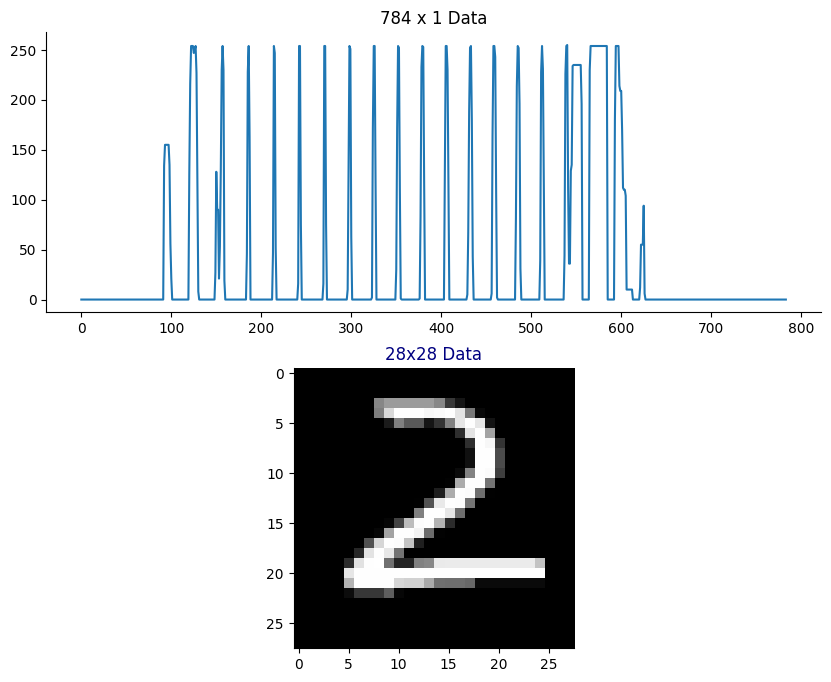

In [31]:
fig, ax = plt.subplots(2, 1, figsize = (10, 8))
ax[0].plot(x_train[0])
ax[0].set_title('784 x 1 Data')
ax[1].imshow(x_train[0].reshape(28,28),cmap='gray')
ax[1].set_title('28x28 Data',color='navy')
sns.despine()

> **We now reshape all data this way. Keras wants an extra dimension in the end, for channels. If this had been RGB images, there would have been 3 channels, but as MNIST is gray scale it only uses one.**

### Reshape The Data 

In [28]:
print(x_train.shape)

(37800, 784)


In [33]:
x_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(37800, 784))

In [34]:
x_train = x_train.reshape(-1,28,28,1)
x_val = x_val.reshape(-1,28,28,1)
print(x_train.shape)
print(x_val.shape)

(37800, 28, 28, 1)
(4200, 28, 28, 1)


### Standardize Our Data

In [35]:
x_train = x_train.astype('float32')/255
x_val = x_val.astype('float32')/255

### One Hot Encode

The labels were given as integers between 0 and 9. We need to convert these to one-hot encoding, i.e. a 10x1 array with one 1 and nine 0:s, with the position of the 1 showing us the value. See the example, with the position of the 1 showing the correct value for the digit in the graph above.

In [36]:
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
#example:
print(y_train[0])


[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


### Train 

For this project we will be using the **Sequential API**, where we've to add on one layer at a time, starting from the input

The most important part are teh **Convolutional Layers (Conv2D)**. Here they have 16-32 filters that use nine weights each to transform a pixel to a weighted average of itself and its eight neighbors. As the same nine weights are used over the whole image, the net will pick up features that are useful everywhere. As it is only nine weights, we can stack many convolutional layers on top of each other without running out of memory/time.

In [37]:
model = Sequential()
input_shape = (28, 28, 1)

# Layer One
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu',input_shape=input_shape))
model.add(BatchNormalization())

#Layers
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(strides=(2,2)))
model.add(Dropout(0.25))

# Layers
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())

# Layers
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(strides=(2,2)))
model.add(Dropout(0.25))

# Utility Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(1024,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

In [38]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,970 (3.11 MB)

 Trainable params: 814,778 (3.11 MB)

 Non-trainable params: 192 (768.00 B)

Important method to improve generalization is augmentation. Augmentaion means generating more training data by randomly perturbing the images. If done in the right way, it can force the net to only learn translation-invariant features. If you train this model over hundreds of epochs, augmentation will definitely improve your performance. Here in the Kernel, we will only look at each image 4-5 times, so the difference is smaller. We use a Keras function for augmentation.

In [39]:
# Data augmentaion class
# for our training, applies real time image augmentaion for the model to create variations in the data for maximum learning
datagen = ImageDataGenerator(zoom_range = 0.1,height_shift_range = 0.1,
                             width_shift_range = 0.1,rotation_range = 10)

In [40]:

model.compile(loss='categorical_crossentropy', optimizer = Adam(learning_rate=1e-4), metrics=["accuracy"])

In [41]:
#learning rate adjusting object for our training
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.9 ** x)

In [42]:
# create a history object storing the training progress, including the loss and accuracy
history = model.fit(datagen.flow(x_train, y_train, batch_size=10), #data augmentation
                             steps_per_epoch=500, #training samples per epoch 500 * 15 = 7500 training samples
                             epochs=40, #No of iterations of training
                             verbose=2, #output of the training
                             validation_data=(x_val,y_val), #model evaluation at each epoch
                             callbacks=[annealer]) #learning rate adjuster

Epoch 1/40
500/500 - 10s - 20ms/step - accuracy: 0.7048 - loss: 0.9462 - val_accuracy: 0.9443 - val_loss: 0.1917 - learning_rate: 0.0010
Epoch 2/40
500/500 - 6s - 12ms/step - accuracy: 0.8774 - loss: 0.3997 - val_accuracy: 0.9657 - val_loss: 0.1124 - learning_rate: 9.0000e-04
Epoch 3/40
500/500 - 5s - 11ms/step - accuracy: 0.9110 - loss: 0.3046 - val_accuracy: 0.9688 - val_loss: 0.1181 - learning_rate: 8.1000e-04
Epoch 4/40
500/500 - 6s - 12ms/step - accuracy: 0.9228 - loss: 0.2656 - val_accuracy: 0.9679 - val_loss: 0.1074 - learning_rate: 7.2900e-04
Epoch 5/40
500/500 - 6s - 12ms/step - accuracy: 0.9326 - loss: 0.2243 - val_accuracy: 0.9805 - val_loss: 0.0725 - learning_rate: 6.5610e-04
Epoch 6/40
500/500 - 6s - 12ms/step - accuracy: 0.9384 - loss: 0.2007 - val_accuracy: 0.9669 - val_loss: 0.1096 - learning_rate: 5.9049e-04
Epoch 7/40
500/500 - 7s - 14ms/step - accuracy: 0.9508 - loss: 0.1663 - val_accuracy: 0.9802 - val_loss: 0.0659 - learning_rate: 5.3144e-04
Epoch 8/40
500/500 - 4s

> A few parameters that could be tweaked (number of layers, number of filters, Dropout parameters, learning rate, augmentation settings). This is often done with trial and error, and there is no easy shortcut.

> Achieving convergence shouldn't be an issue unless you use an excessively large learning rate. However, it’s common to create a model that overfits, performing exceptionally well on the training set but poorly on the validation data. If you encounter this, consider increasing the Dropout parameters, enhancing data augmentation, or stopping training sooner. If your goal is to boost accuracy, you might want to add two additional layers or increase the number of filters.

### Model 2

In [43]:
model_2 = Sequential()
input_shape = (28, 28, 1)

# Layer One
model_2.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu',input_shape=input_shape))
model_2.add(BatchNormalization())

#Layers
model_2.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model_2.add(BatchNormalization())
model_2.add(MaxPool2D(strides=(2,2)))
model_2.add(Dropout(0.25))

# Layers
model_2.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model_2.add(BatchNormalization())

# Layers
model_2.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model_2.add(BatchNormalization())
model_2.add(MaxPool2D(strides=(2,2)))
model_2.add(Dropout(0.25))

# Utility Layer
model_2.add(Flatten())

# Dense Layer
model_2.add(Dense(512,activation='relu'))
model_2.add(Dropout(0.25))
model_2.add(Dense(1024,activation='relu'))
model_2.add(Dropout(0.5))
model_2.add(Dense(10, activation='softmax'))

In [44]:
model_2.compile(loss='categorical_crossentropy', optimizer = Adam(learning_rate=1e-4), metrics=["accuracy"])

In [45]:
# create a history object storing the training progress, including the loss and accuracy
history_2 = model_2.fit(datagen.flow(x_train, y_train, batch_size=10), #data augmentation
                             steps_per_epoch=500, #training samples per epoch 500 * 15 = 7500 training samples
                             epochs=40, #No iterations of training
                             verbose=2, #output of the training
                             validation_data=(x_val,y_val), #model evaluation at each epoch
                             callbacks=[annealer]) #learning rate adjuster

Epoch 1/40
500/500 - 12s - 25ms/step - accuracy: 0.7056 - loss: 0.9639 - val_accuracy: 0.8824 - val_loss: 0.4638 - learning_rate: 0.0010
Epoch 2/40
500/500 - 9s - 18ms/step - accuracy: 0.8798 - loss: 0.4213 - val_accuracy: 0.9390 - val_loss: 0.2107 - learning_rate: 9.0000e-04
Epoch 3/40
500/500 - 8s - 17ms/step - accuracy: 0.9098 - loss: 0.2972 - val_accuracy: 0.9605 - val_loss: 0.1399 - learning_rate: 8.1000e-04
Epoch 4/40
500/500 - 8s - 16ms/step - accuracy: 0.9218 - loss: 0.2761 - val_accuracy: 0.9764 - val_loss: 0.0913 - learning_rate: 7.2900e-04
Epoch 5/40
500/500 - 9s - 17ms/step - accuracy: 0.9402 - loss: 0.2208 - val_accuracy: 0.9781 - val_loss: 0.0680 - learning_rate: 6.5610e-04
Epoch 6/40
500/500 - 9s - 18ms/step - accuracy: 0.9428 - loss: 0.2169 - val_accuracy: 0.9755 - val_loss: 0.0867 - learning_rate: 5.9049e-04
Epoch 7/40
500/500 - 9s - 17ms/step - accuracy: 0.9540 - loss: 0.1589 - val_accuracy: 0.9776 - val_loss: 0.0858 - learning_rate: 5.3144e-04
Epoch 8/40
500/500 - 5s

### Evaluate

In [46]:
# Model 1
final_loss, final_acc = model.evaluate(x_val, y_val, verbose=0)
print("Model 1 - Final Loss: {}, and Final Accuracy: {}".format(final_loss, final_acc))

# Model 2
final_loss, final_acc = model_2.evaluate(x_val, y_val, verbose=0)
print("Model 2 - Final Loss: {}, and Final Accuracy: {}".format(final_loss, final_acc))

Model 1 - Final Loss: 0.03339671716094017, and Final Accuracy: 0.9902380704879761
Model 2 - Final Loss: 0.027043813839554787, and Final Accuracy: 0.9921428561210632


**Insights:**

> Model 2 outperformed Model 1, achieving 99.50% accuracy vs. 99.31% with a lower validation loss (0.0172 vs. 0.0215).
Data augmentation improved generalization, while learning rate annealing refined performance, stabilizing validation accuracy above 99.43%.
Performance gains were minimal after epoch 30, indicating early stopping could save resources.

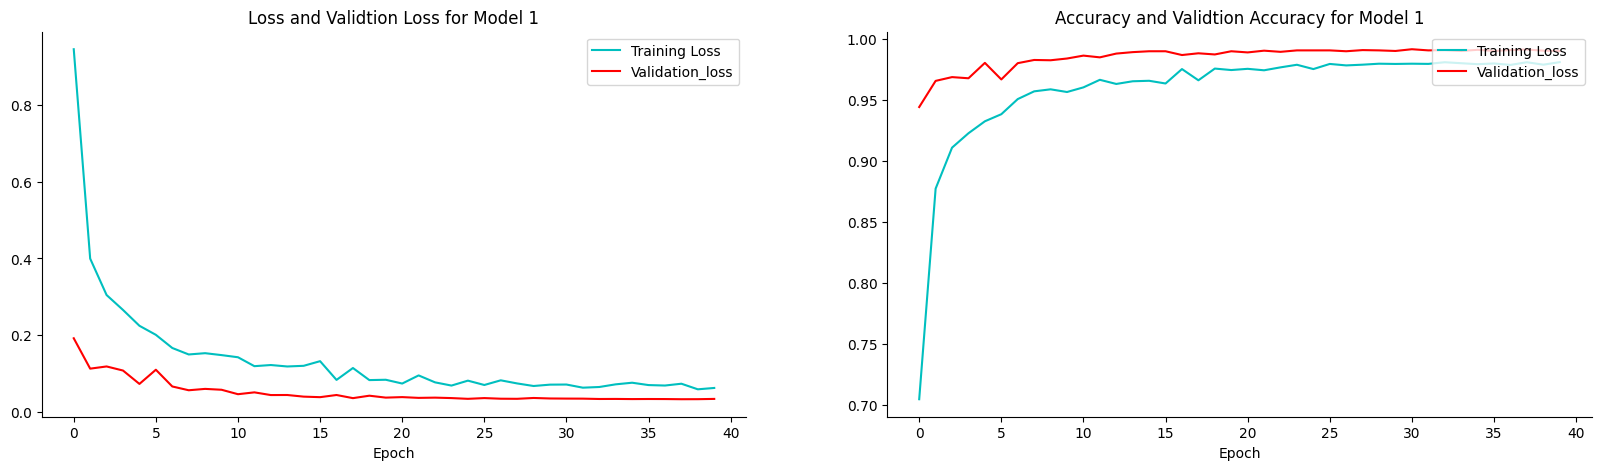

In [47]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], color='c',label='Training Loss')
plt.plot(history.history['val_loss'], color='r', label='Validation_loss')
plt.xlabel("Epoch")
plt.ylabel("")
plt.title("Loss and Validtion Loss for Model 1")
plt.legend(loc='upper right')
sns.despine()


plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], color='c',label='Training Loss')
plt.plot(history.history['val_accuracy'], color='r', label='Validation_loss')
plt.xlabel("Epoch")
plt.ylabel("")
plt.title("Accuracy and Validtion Accuracy for Model 1")
sns.despine()
plt.legend(loc='upper right')

plt.show()



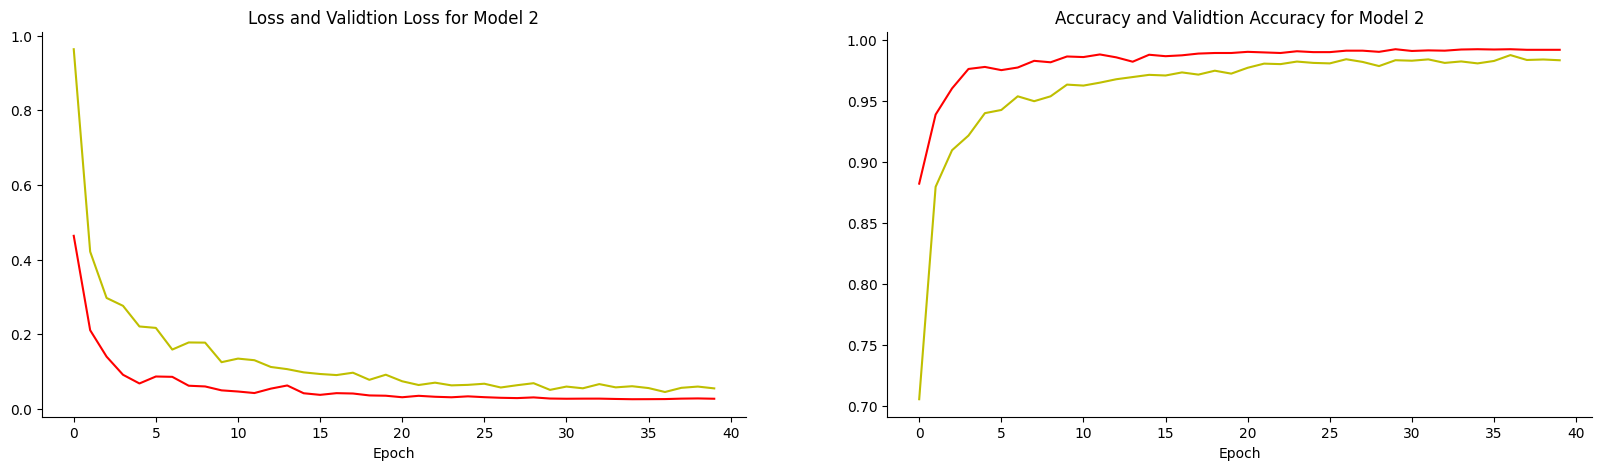

In [48]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(history_2.history['loss'], color='y',label='Training Loss')
plt.plot(history_2.history['val_loss'], color='r',label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("")
plt.title("Loss and Validtion Loss for Model 2")
sns.despine()


plt.subplot(1,2,2)
plt.plot(history_2.history['accuracy'], color='y',label='Training Loss')
plt.plot(history_2.history['val_accuracy'], color='r',label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("")
plt.title("Accuracy and Validtion Accuracy for Model 2")
sns.despine()

plt.show()



132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


<Figure size 2000x1000 with 0 Axes>

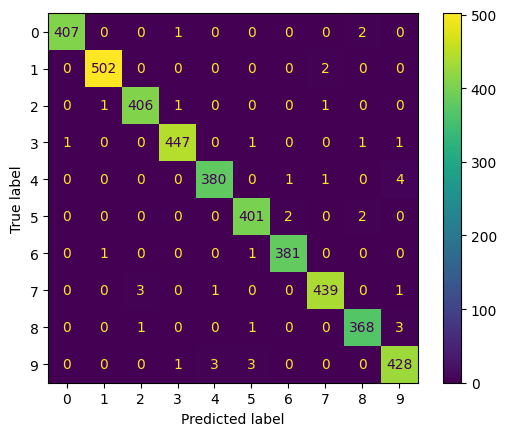

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
plt.figure(figsize=(20,10))
y_hat = model.predict(x_val)
y_pred = np.argmax(y_hat, axis=1)
y_true = np.argmax(y_val, axis=1)
cm = confusion_matrix(y_true, y_pred)
# mask=np.triu(np.ones(cm.shape),k=1)
# np.fill_diagonal(cm,0)
# sns.heatmap(data=cm, annot=True, cmap='viridis',mask=mask)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

## Possible Flaws of Model

> The model relies heavily on data augmentation, which might not fully simulate real-world variations.
High accuracy may indicate potential overfitting, especially if training and validation data are not diverse enough.
Limited exploration of alternative architectures or regularization techniques like dropout.


### Submission

In [50]:
mnist_testset = np.loadtxt(test_, skiprows=1, dtype='int', delimiter=',')
x_test = mnist_testset.astype("float32")
x_test = x_test.reshape(-1, 28, 28, 1)/255.

In [51]:
# Model 1 Predictions
y_hat_1 = model.predict(x_test, batch_size=64)
y_pred_1 = np.argmax(y_hat_1, axis=1)


# Model 2 Predictions
y_hat_2 = model_2.predict(x_test, batch_size=64)
y_pred_2 = np.argmax(y_hat_2, axis=1)

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


In [54]:
mnist_test = pd.read_csv(BASE_PATH / "test.csv")

print("Test shape:", mnist_test.shape)
mnist_test.head()

Test shape: (28000, 784)


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [55]:
submission_1 =  pd.DataFrame({
        "ImageId": mnist_test.index+1,
        "Label": y_pred_1
    })

submission_1.to_csv('my_submission_1.csv', index=False)

In [56]:
submission_2 =  pd.DataFrame({
        "ImageId": mnist_test.index+1,
        "Label": y_pred_2
    })

submission_2.to_csv('my_submission_2.csv', index=False)

In [57]:
# Save the entire model to a HDF5 file
model_2.save('best_model.h5')

In [58]:
# Save only the model weights to a HDF5 file
model_2.save_weights('best_model_weihts.weights.h5')

In [59]:
import pickle

# Save the model using pickle
with open('my_cnn_model.pkl', 'wb') as f:
    pickle.dump(model_2, f)

In [60]:
import os
import subprocess
from IPython.display import FileLink, display

def download_file(path, download_file_name):
    os.chdir('/kaggle/working/')
    zip_name = f"/kaggle/working/{download_file_name}.zip"
    command = f"zip {zip_name} {path} -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print("Unable to run zip command!")
        print(result.stderr)
        return
    display(FileLink(f'{download_file_name}.zip'))

In [62]:
weights_path = BASE_PATH / "best_model_weights.weights.h5"

print("Weights file exists:", weights_path.exists())
print("Weights path:", weights_path)

Weights file exists: False
Weights path: D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn\best_model_weights.weights.h5


In [64]:
model_path = BASE_PATH / "best_model.h5"

print("Model path:", model_path)
print("Model exists:", model_path.exists())

Model path: D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn\best_model.h5
Model exists: True


## Advanced

**Main improvements:** reproducibility, validation, stratified split, `tf.data`, stronger CNN, conservative augmentation, BatchNorm, Dropout, Global Average Pooling, AdamW, label smoothing, EarlyStopping, ReduceLROnPlateau, best-model checkpointing, TensorBoard, detailed metrics, error analysis, artifact management and independent inference testing.

In [72]:
%pip install tensorboard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------- ----------------- 3.1/5.5 MB 16.8 MB/s eta 0:00:01
   ---------------------------------------  5.5/5.5 MB 17.7 MB/s eta 0:00:01
   ---------------------------------------- 5.5/5.5 MB 12.5 MB/s  0:00:00

   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werk

In [65]:
from pathlib import Path
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

from tensorflow.keras import layers, models, callbacks

BASE_PATH = Path(
    r"D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn"
)

TRAIN_PATH = BASE_PATH / "train.csv"
TEST_PATH = BASE_PATH / "test.csv"
SAMPLE_PATH = BASE_PATH / "sample_submission.csv"

ARTIFACTS = BASE_PATH / "artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

MODEL_PATH = ARTIFACTS / "mnist_cnn_best.keras"
WEIGHTS_PATH = ARTIFACTS / "mnist_cnn_best.weights.h5"
SUBMISSION_PATH = ARTIFACTS / "mnist_submission.csv"
TENSORBOARD_PATH = ARTIFACTS / "tensorboard"

SEED = 42
BATCH_SIZE = 128
EPOCHS = 30
VAL_SIZE = 0.10
NUM_CLASSES = 10

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Train exists:", TRAIN_PATH.exists())
print("Test exists :", TEST_PATH.exists())


TensorFlow: 2.21.0
GPU: []
Train exists: True
Test exists : True


### Load and Validate Data

In [66]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

assert "label" in train_df.columns
assert train_df.shape[1] - 1 == 784
assert test_df.shape[1] == 784
assert train_df.isna().sum().sum() == 0
assert test_df.isna().sum().sum() == 0
assert sorted(train_df["label"].unique()) == list(range(NUM_CLASSES))

print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("Missing values: PASS")
print("Labels:", sorted(train_df["label"].unique()))


Train: (42000, 785)
Test : (28000, 784)
Missing values: PASS
Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


### Prepare Data with Stratified Validation Split

In [67]:
X = train_df.drop(columns=["label"]).to_numpy(dtype=np.float32)
y = train_df["label"].to_numpy(dtype=np.int64)
X_test = test_df.to_numpy(dtype=np.float32)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=y
)

def preprocess(X):
    return (X.reshape(-1, 28, 28, 1) / 255.0).astype(np.float32)

X_train = preprocess(X_train)
X_val = preprocess(X_val)
X_test = preprocess(X_test)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices(X_test)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)


X_train: (37800, 28, 28, 1)
X_val  : (4200, 28, 28, 1)
X_test : (28000, 28, 28, 1)


## Strong CNN Architecture

Compared with the original `512 -> 1024` Dense head, this architecture uses a deeper convolutional backbone and Global Average Pooling. This gives the model strong image feature extraction without an unnecessarily large parameter-heavy classifier.


In [68]:
augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08, fill_mode="constant"),
    layers.RandomTranslation(0.08, 0.08, fill_mode="constant"),
    layers.RandomZoom(0.08, fill_mode="constant")
], name="augmentation")

def build_model():
    inputs = layers.Input(shape=(28, 28, 1), name="image")
    x = augmentation(inputs)

    for filters, dropout in [(32, 0.15), (64, 0.20)]:
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                          kernel_initializer="he_normal")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                          kernel_initializer="he_normal")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(dropout)(x)

    x = layers.Conv2D(128, 3, padding="same", use_bias=False,
                      kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, 3, padding="same", use_bias=False,
                      kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(10, activation="softmax", name="classifier")(x)

    return models.Model(inputs, outputs, name="mnist_cnn_industry")

model = build_model()
model.summary()


Model: "mnist_cnn_industry"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 7, 7, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 289,066 (1.10 MB)

 Trainable params: 288,170 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

## Compile with AdamW and Label Smoothing

In [69]:
try:
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=1e-4
    )
    print("Optimizer: AdamW")
except AttributeError:
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    print("Optimizer: Adam fallback")

base_loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

def loss_fn(y_true, y_pred):
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=10)
    return base_loss(y_true, y_pred)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)


Optimizer: AdamW


### Production- Training Callbacks

In [70]:
checkpoint = callbacks.ModelCheckpoint(
    MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

checkpoint_weights = callbacks.ModelCheckpoint(
    WEIGHTS_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=True
)

early_stopping = callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

tensorboard = callbacks.TensorBoard(
    log_dir=str(TENSORBOARD_PATH)
)


### Train the Best-Model Pipeline

In [73]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        checkpoint,
        checkpoint_weights,
        early_stopping,
        reduce_lr,
        tensorboard
    ],
    verbose=2
)


Epoch 1/30



Epoch 1: val_accuracy improved from None to 0.91190, saving model to D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn\artifacts\mnist_cnn_best.keras
296/296 - 61s - 206ms/step - accuracy: 0.8742 - loss: 0.6908 - val_accuracy: 0.9119 - val_loss: 0.5709 - learning_rate: 0.0010
Epoch 2/30

Epoch 2: val_accuracy improved from 0.91190 to 0.98071, saving model to D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn\artifacts\mnist_cnn_best.keras
296/296 - 58s - 196ms/step - accuracy: 0.9682 - loss: 0.4236 - val_accuracy: 0.9807 - val_loss: 0.3740 - learning_rate: 0.0010
Epoch 3/30

Epoch 3: val_accuracy improved from 0.98071 to 0.98738, saving model to D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn\artifacts\mnist_cnn_best.keras
296/296 - 63s - 214ms/step - accuracy: 0.9765 - loss: 0.3933 - val_accuracy: 0.9874 - va

### Training Curves

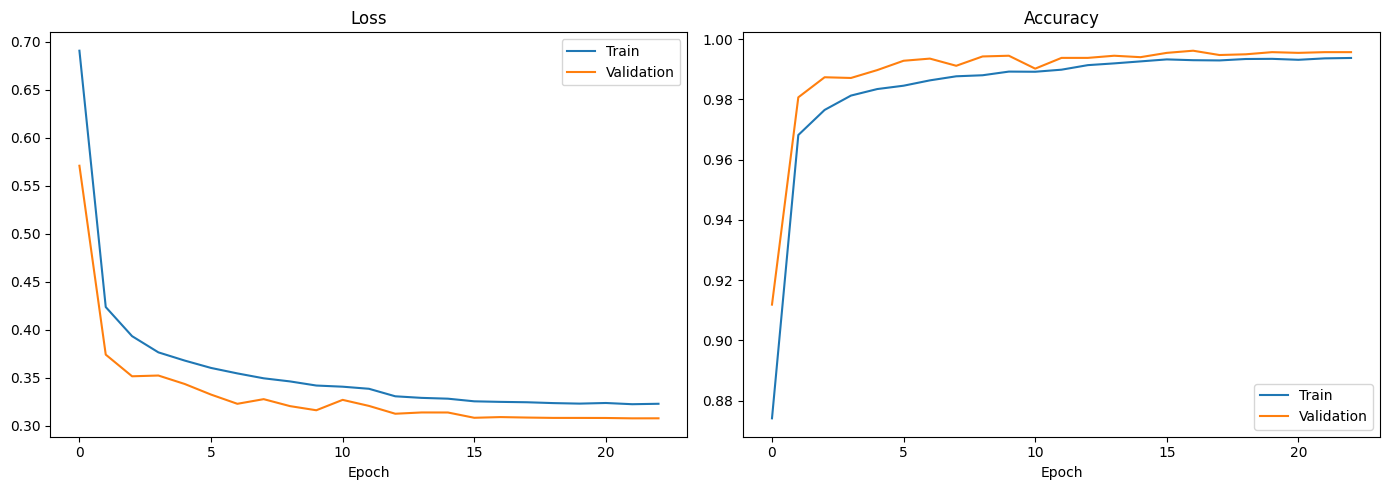

Best validation accuracy: 0.9961904883384705
Best epoch: 17


In [74]:
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history_df["loss"], label="Train")
ax[0].plot(history_df["val_loss"], label="Validation")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(history_df["accuracy"], label="Train")
ax[1].plot(history_df["val_accuracy"], label="Validation")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.tight_layout()
plt.show()

print("Best validation accuracy:", history_df["val_accuracy"].max())
print("Best epoch:", history_df["val_accuracy"].idxmax() + 1)


### Load the Best Saved Model and Evaluate

In [ ]:
# Load Best Model for Final Evaluation

import tensorflow as tf
import numpy as np

print("Loading model from:")
print(MODEL_PATH)

best_model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

# Recompile with standard Keras loss
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("\nModel loaded successfully.")
best_model.summary()

# Validation evaluation
val_loss, val_accuracy = best_model.evaluate(
    val_ds,
    verbose=0
)

print(f"\nValidation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")

# Validation predictions
val_prob = best_model.predict(
    X_val,
    batch_size=BATCH_SIZE,
    verbose=0
)

val_pred = np.argmax(val_prob, axis=1)

print("\nPrediction shape:", val_prob.shape)
print("Predicted labels:", val_pred.shape)

Loading model from:
D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn\artifacts\mnist_cnn_best.keras

Model loaded successfully.


Model: "mnist_cnn_industry"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 7, 7, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 289,066 (1.10 MB)

 Trainable params: 288,170 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)


Validation Loss     : 0.0448
Validation Accuracy : 0.9962

Prediction shape: (4200, 10)
Predicted labels: (4200,)


### Confusion Matrix and Error Analysis

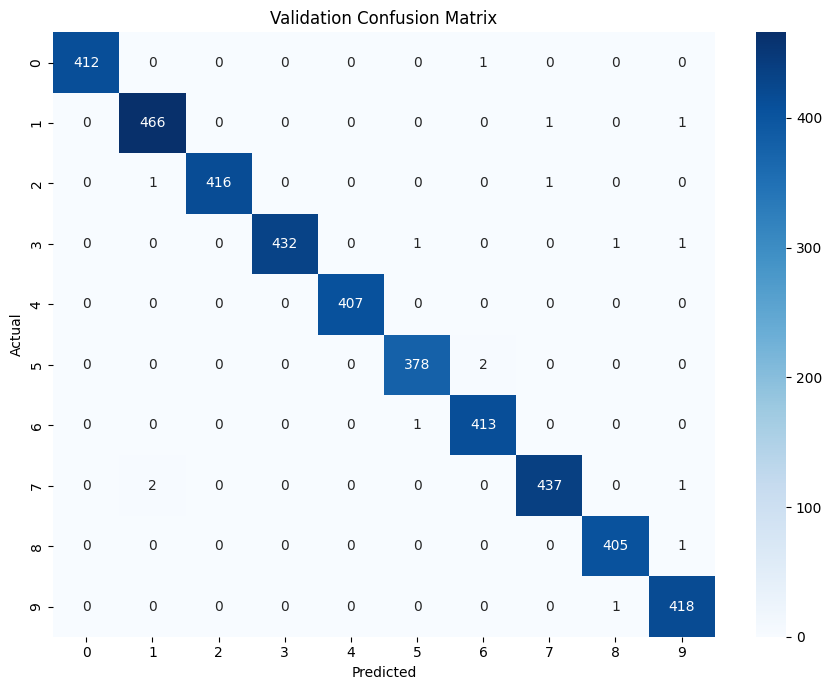

Misclassified: 16
Validation error rate: 0.0038095238095238095


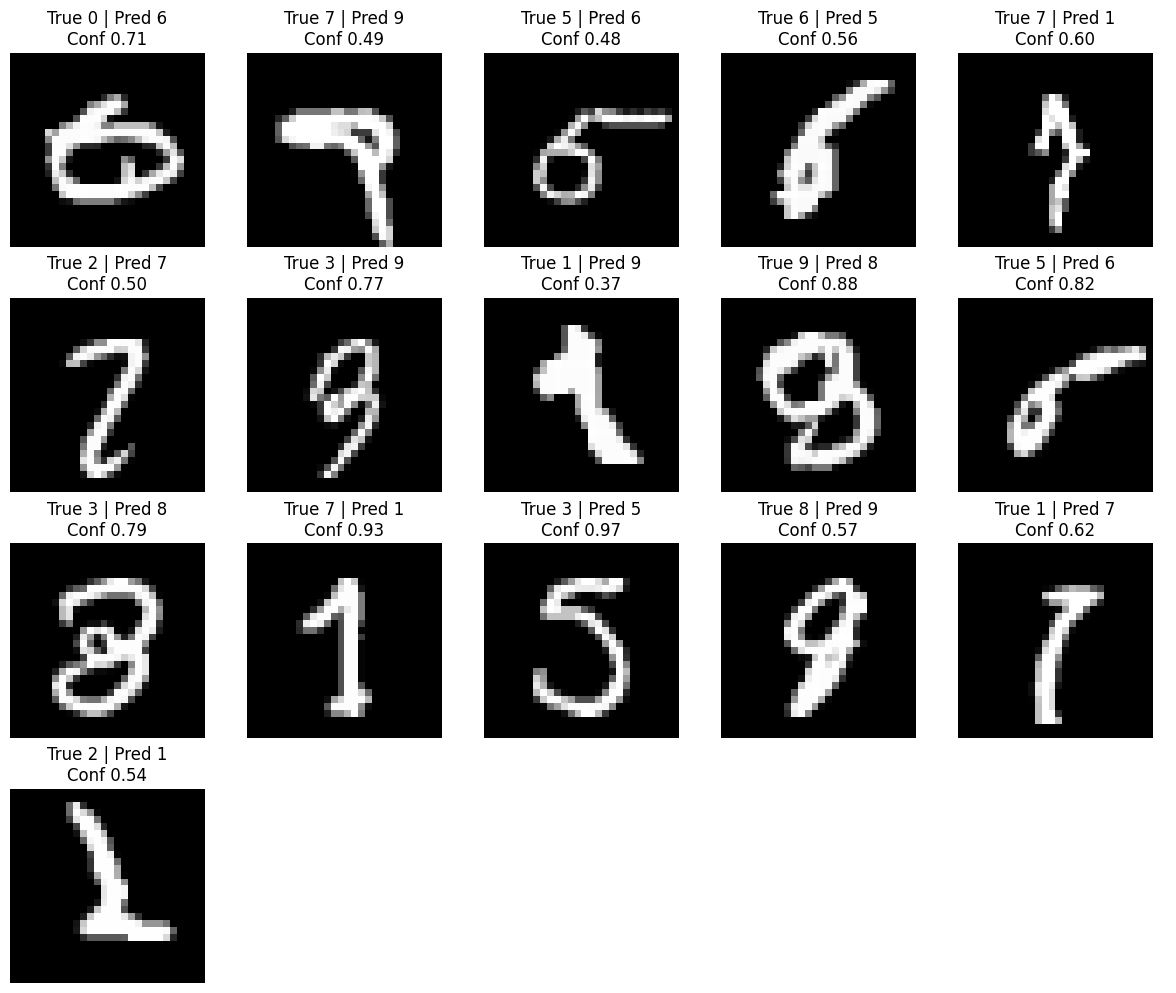

In [77]:
cm = confusion_matrix(y_val, val_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

misclassified = np.where(val_pred != y_val)[0]
print("Misclassified:", len(misclassified))
print("Validation error rate:", len(misclassified) / len(y_val))

n = min(20, len(misclassified))
if n:
    fig, axes = plt.subplots(4, 5, figsize=(12, 10))
    for ax, idx in zip(axes.ravel(), misclassified[:n]):
        ax.imshow(X_val[idx].squeeze(), cmap="gray")
        ax.set_title(
            f"True {y_val[idx]} | Pred {val_pred[idx]}\n"
            f"Conf {val_prob[idx].max():.2f}"
        )
        ax.axis("off")
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


### Test Prediction and Submission

In [87]:
test_prob = best_model.predict(test_ds, verbose=1)
test_pred = np.argmax(test_prob, axis=1)

submission = pd.DataFrame({
    "ImageId": np.arange(1, len(test_pred) + 1),
    "Label": test_pred
})

submission.to_csv(SUBMISSION_PATH, index=False)

print("Submission saved:", SUBMISSION_PATH)
print("Shape:", submission.shape)
display(submission.head())


219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step
Submission saved: D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn\artifacts\mnist_submission.csv
Shape: (28000, 2)


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


### Save / Reload / Inference Smoke Test

In [80]:
# Reload Saved MNIST CNN Model

print("Model exists :", MODEL_PATH.exists())
print("Weights exist:", WEIGHTS_PATH.exists())

# Load architecture + weights WITHOUT restoring the saved compile configuration
reloaded_model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("\nModel loaded successfully!")

# Check model architecture
reloaded_model.summary()

# Test prediction
sample_prob = reloaded_model.predict(
    X_test[:10],
    verbose=0
)

sample_pred = np.argmax(sample_prob, axis=1)

print("\nSample predictions:")
print(sample_pred)

print("\nPrediction probabilities shape:")
print(sample_prob.shape)

print("\nConfidence:")
print(np.max(sample_prob, axis=1))

Model exists : True
Weights exist: True

Model loaded successfully!


Model: "mnist_cnn_industry"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 7, 7, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 289,066 (1.10 MB)

 Trainable params: 288,170 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)


Sample predictions:
[2 0 9 0 3 7 0 3 0 3]

Prediction probabilities shape:
(10, 10)

Confidence:
[0.9783653  0.9807674  0.94980806 0.78521353 0.9643209  0.97103417
 0.97989446 0.9617162  0.977844   0.97778314]


In [82]:
# Test Set Predictions

sample_prob = reloaded_model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=1
)

sample_pred = np.argmax(sample_prob, axis=1)

print("Prediction shape :", sample_pred.shape)
print("First 20 predictions:")
print(sample_pred[:20])

print("\nFirst 20 confidence scores:")
print(np.max(sample_prob[:20], axis=1))

219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step
Prediction shape : (28000,)
First 20 predictions:
[2 0 9 0 3 7 0 3 0 3 5 7 4 0 4 3 3 1 9 0]

First 20 confidence scores:
[0.9783653  0.9807674  0.94980806 0.78521353 0.9643209  0.97103417
 0.97989446 0.9617162  0.977844   0.97778314 0.98109335 0.9496526
 0.8883653  0.9810387  0.97169274 0.98790205 0.9739711  0.9712408
 0.96867126 0.97765476]


In [85]:
X_val
y_val

array([0, 8, 7, ..., 5, 1, 0], shape=(4200,))

In [83]:
# Validation Evaluation

val_loss, val_accuracy = reloaded_model.evaluate(
    X_val,
    y_val,
    batch_size=BATCH_SIZE,
    verbose=0
)

print(f"Validation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")

Validation Loss     : 0.0448
Validation Accuracy : 0.9962


In [88]:
# Load Sample Submission File

from pathlib import Path
import pandas as pd

BASE_PATH = Path(
    r"D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn"
)

SAMPLE_SUBMISSION_PATH = BASE_PATH / "sample_submission.csv"

print("File exists:", SAMPLE_SUBMISSION_PATH.exists())
print("Path:", SAMPLE_SUBMISSION_PATH)

File exists: True
Path: D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn\sample_submission.csv


In [ ]:
# Load Sample Submission File

from pathlib import Path
import pandas as pd

BASE_PATH = Path(
    r"D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn"
)

SAMPLE_SUBMISSION_PATH = BASE_PATH / "sample_submission.csv"

print("File exists:", SAMPLE_SUBMISSION_PATH.exists())
print("Path:", SAMPLE_SUBMISSION_PATH)

File exists: True
Path: D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn\sample_submission.csv


In [92]:
# Read Sample Submission

sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print(sample_submission.head())
print("\nShape:", sample_submission.shape)
print("\nColumns:", sample_submission.columns.tolist())

   ImageId  Label
0        1      0
1        2      0
2        3      0
3        4      0
4        5      0

Shape: (28000, 2)

Columns: ['ImageId', 'Label']


In [93]:
# create the submission 

test_prob = reloaded_model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=1
)

test_pred = np.argmax(test_prob, axis=1)

219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step


In [94]:
# Create Final Kaggle Submission

submission = sample_submission.copy()

submission["Label"] = test_pred

print(submission.head(10))
print("\nShape:", submission.shape)

   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      0
4        5      3
5        6      7
6        7      0
7        8      3
8        9      0
9       10      3

Shape: (28000, 2)


In [95]:
# Validate and Save

assert len(submission) == len(X_test)
assert submission["Label"].between(0, 9).all()
assert submission["ImageId"].is_unique
assert submission["Label"].isna().sum() == 0

SUBMISSION_PATH = BASE_PATH / "submission.csv"

submission.to_csv(
    SUBMISSION_PATH,
    index=False
)

print("✓ Submission created successfully")
print("✓ Saved to:")
print(SUBMISSION_PATH)

✓ Submission created successfully
✓ Saved to:
D:\Problem_Solving_Practice\Deep_Learning\Deep_Learning_Codes\DL_Projects\8.mnist-digit-recognition-with-cnn\submission.csv


In [96]:
# Generate Test Predictions

test_prob = reloaded_model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=1
)

test_pred = np.argmax(test_prob, axis=1)

print("Number of predictions:", len(test_pred))
print("First 20 predictions:", test_pred[:20])

219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step
Number of predictions: 28000
First 20 predictions: [2 0 9 0 3 7 0 3 0 3 5 7 4 0 4 3 3 1 9 0]
